<a href="https://colab.research.google.com/github/Shavrau/AmFatec2025/blob/main/censo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Censo

##Importação de bibliotecas

In [59]:
!pip install plotly --upgrade

In [60]:
!pip -q install yellowbrick

In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

##Carregamento do dataset

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
base_census = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/am5s/census.csv")

In [64]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


##Exploração inicial

In [65]:
base_census.head()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [66]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [67]:
base_census.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   final-weight    32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loos    32561 non-null  int64 
 12  hour-per-week   32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Campos Categoricos : workclass,education, marital-status, occupation, relationship,race, sex, native-country, c#income

Campos Quantitativos :age, final-weight, education-num, capital-gain, capital-loos, hour-per-week

In [68]:
base_census.isnull().sum()

,0
age,0
workclass,0
final-weight,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


##Visualizações solicitadas

###Distribuições categoricas

<ipython-input-69-5681f06eb078>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




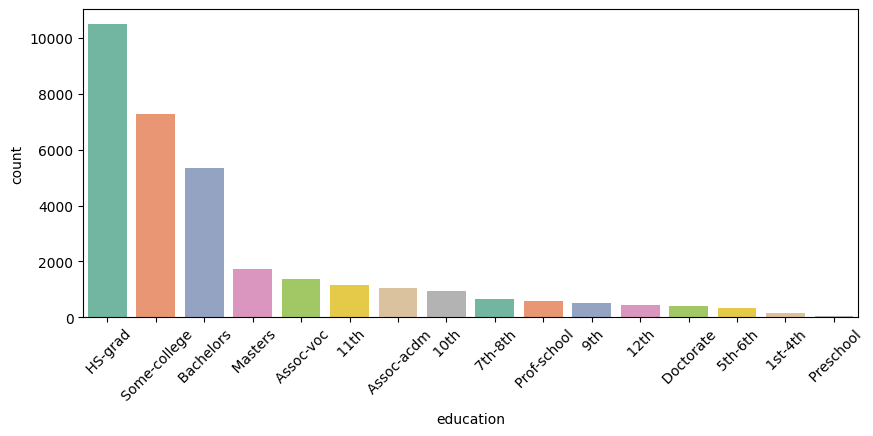

In [69]:
plt.figure(figsize=(10, 4))
sns.countplot(data=base_census, x=base_census['education'], order=base_census['education'].value_counts().index, palette='Set2')
plt.xticks(rotation=45)
plt.show()


<ipython-input-70-e042bb595bec>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




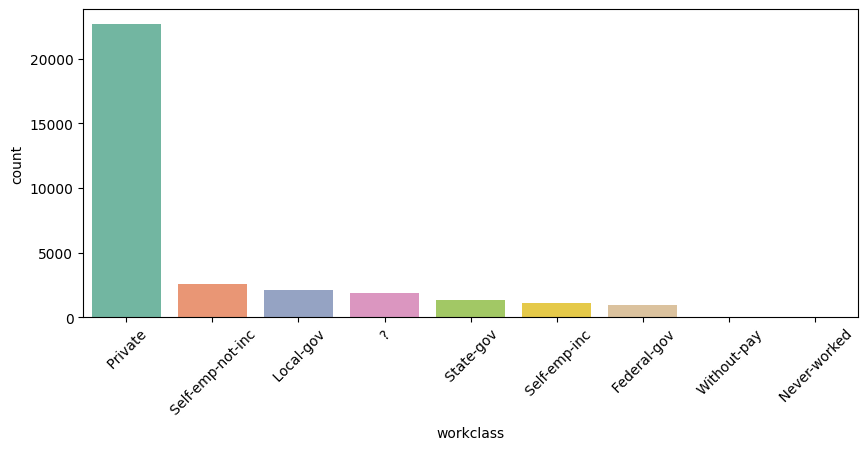

In [70]:
plt.figure(figsize=(10, 4))
sns.countplot(data=base_census, x=base_census['workclass'], order=base_census['workclass'].value_counts().index, palette='Set2')
plt.xticks(rotation=45)
plt.show()


<ipython-input-71-8fe88adf4c34>:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




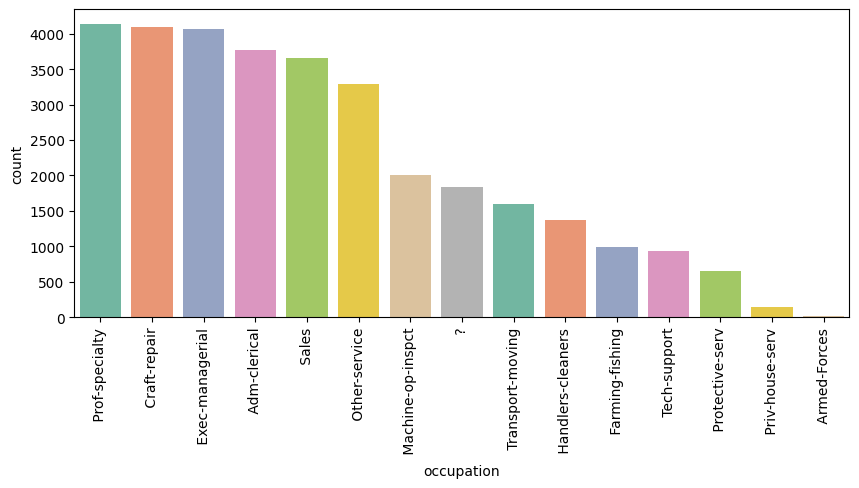

In [71]:
plt.figure(figsize=(10, 4))
sns.countplot(data=base_census, x=base_census['occupation'], order=base_census['occupation'].value_counts().index, palette='Set2')
plt.xticks(rotation=90)
plt.show()


###Ditribuição, histogramas

<Axes: xlabel='income', ylabel='count'>

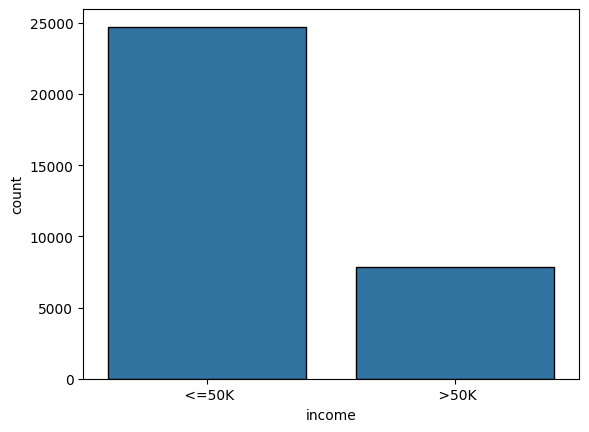

In [72]:
sns.countplot(x = base_census['income'],edgecolor = 'black')

In [121]:
base_census['income'].value_counts()

,count
income,
<=50K,24720
>50K,7841


In [126]:
base_census['income'].count()

np.int64(32561)

In [128]:
2472000/32561

75.91904425539757

(array([5570., 5890., 6048., 6163., 3967., 2591., 1595.,  496.,  174.,
          67.]),
 array([17. , 24.3, 31.6, 38.9, 46.2, 53.5, 60.8, 68.1, 75.4, 82.7, 90. ]),
 <BarContainer object of 10 artists>)

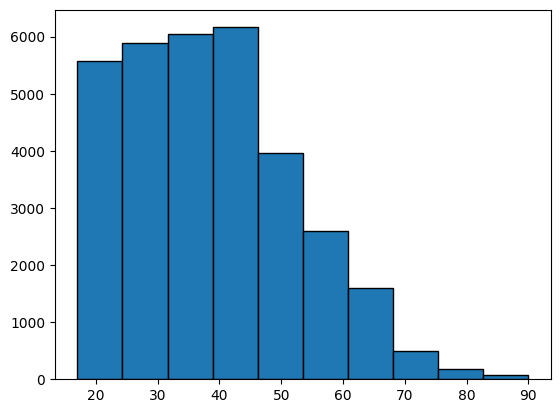

In [73]:
plt.hist(base_census['age'], edgecolor = 'black')

(array([  219.,   333.,  1160.,   933.,  1608., 10501.,  8673.,  1067.,
         7078.,   989.]),
 array([ 1. ,  2.5,  4. ,  5.5,  7. ,  8.5, 10. , 11.5, 13. , 14.5, 16. ]),
 <BarContainer object of 10 artists>)

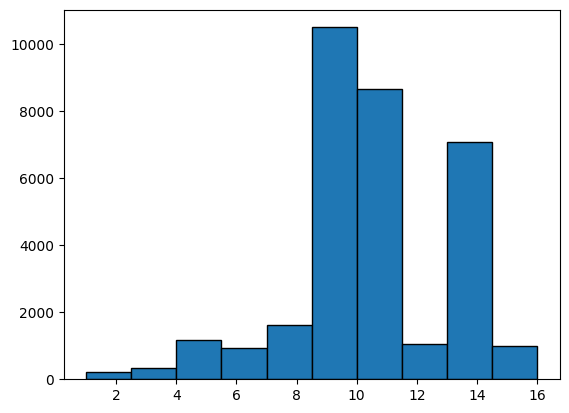

In [74]:
plt.hist(base_census['education-num'],edgecolor = 'black')

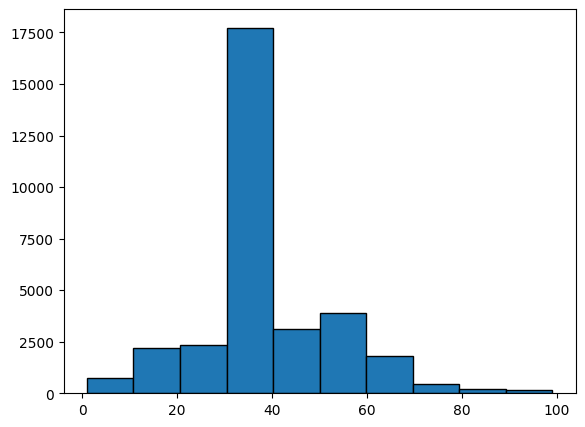

In [75]:
plt.hist(base_census['hour-per-week'], edgecolor = 'black')
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=0.4, hspace=0.4)

In [76]:
np.unique(base_census['income'], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

##Treemaps

In [77]:
arvore_profissao_idade  = px.treemap(base_census, path=['workclass', 'age'])
arvore_profissao_idade.show()

In [78]:
grafico = px.treemap(base_census, path=['occupation', 'relationship', 'age'])
grafico.show()

##Graficos Paralelos

In [79]:
grafico = px.parallel_categories(base_census, dimensions=['education', 'income'])
grafico.show()

In [80]:
grafico = px.parallel_categories(base_census, dimensions=['workclass', 'occupation','income'])
grafico.show()

In [81]:
grafico = px.parallel_categories(base_census, dimensions=['occupation', 'relationship'])
grafico.show()

##Divisão de previsores (Categoricos e numericos) e classes(alvos/resultantes)

In [82]:
base_census.columns

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country',
       'income'],
      dtype='object')

In [83]:
x_census = base_census.iloc[:,0:14].values
x_census

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      dtype=object)

In [84]:
x_census[0]

array([39, ' State-gov', 77516, ' Bachelors', 13, ' Never-married',
       ' Adm-clerical', ' Not-in-family', ' White', ' Male', 2174, 0, 40,
       ' United-States'], dtype=object)

In [85]:
y_census = base_census.iloc[:,14].values
y_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

## Tratamento Categorico

In [101]:
from sklearn.preprocessing import LabelEncoder

In [102]:
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [103]:
x_census[:, 1] = label_encoder_workclass.fit_transform(x_census[:, 1])
x_census[:, 3] = label_encoder_education.fit_transform(x_census[:, 3])
x_census[:, 5] = label_encoder_marital.fit_transform(x_census[:, 5])
x_census[:, 6] = label_encoder_occupation.fit_transform(x_census[:, 6])
x_census[:, 7] = label_encoder_relationship.fit_transform(x_census[:, 7])
x_census[:, 8] = label_encoder_race.fit_transform(x_census[:, 8])
x_census[:, 9] = label_encoder_sex.fit_transform(x_census[:, 9])
x_census[:, 13] = label_encoder_country.fit_transform(x_census[:, 13])

##Tratamento OneHotEncoder

In [104]:
len(np.unique(base_census['workclass']))

9

In [105]:
len(np.unique(base_census['occupation']))

15

In [106]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [107]:
onehotencoder_census = ColumnTransformer(
    transformers=[(
        'OneHot', OneHotEncoder(),
        [1,3,5,6,7,8,9,13])],
     remainder='passthrough')

In [109]:
x_census = onehotencoder_census.fit_transform(x_census)

In [112]:
x_census

array([[1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 2.1740e+03, 0.0000e+00,
        4.0000e+01],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.3000e+01],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+01],
       [1.0000e+00, 0.0000e+00, 1.0000e+00, ..., 1.5024e+04, 0.0000e+00,
        4.0000e+01]])

In [116]:
from sklearn.preprocessing import StandardScaler
scalar_census = StandardScaler()
x_census = scalar_census.fit_transform(x_census)

In [117]:
x_census

array([[ 0.17429511, -0.17429511,  0.01466381, ...,  0.1484529 ,
        -0.21665953, -0.03542945],
       [ 0.17429511, -0.17429511,  0.01466381, ..., -0.14592048,
        -0.21665953, -2.22215312],
       [ 0.17429511, -0.17429511,  0.01466381, ..., -0.14592048,
        -0.21665953, -0.03542945],
       ...,
       [ 0.17429511, -0.17429511,  0.01466381, ..., -0.14592048,
        -0.21665953, -0.03542945],
       [ 0.17429511, -0.17429511,  0.01466381, ..., -0.14592048,
        -0.21665953, -1.65522476],
       [ 0.17429511, -0.17429511,  0.01466381, ...,  1.88842434,
        -0.21665953, -0.03542945]])

In [118]:
from sklearn.model_selection import train_test_split

In [129]:
x_census_treinamento, x_census_teste, y_census_treinamento, y_census_teste = train_test_split(x_census, y_census, test_size=0.25, random_state=0)

##Criação Arquivo Binario

In [131]:
import pickle

with open('/content/drive/MyDrive/ColabNotebooks/am5s/pickle/census.pkl', 'wb') as f:
  pickle.dump([x_census_treinamento, y_census_treinamento, x_census_teste, x_census_teste], f)